![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Análisis de sentimientos y técnicas de NLP

En este taller podrán poner en práctica sus conocimientos sobre las diferentes técnicas para el procesamiento de lenguaje natural. El taller está constituido por 5 puntos, en los cuales deberan seguir las intrucciones de cada numeral para su desarrollo.

## Datos predicción sentimientos de viajeros en Twitter

En este taller se usará el conjunto de datos de sentimientos sobre distintas aerolíneas de EE.UU. provenientes de Twitter. Cada observación contiene si el sentimiento de los tweets es positivo, neutral o negativo teniendo en cuenta distintas variables como aerolínea y las razones de los sentimientos negativos (como "retraso en el vuelo" o "servicio grosero"). El objetivo es predecir el sentimiento asociado a cada tweet. Para más detalles pueden visitar el siguiente enlace: [datos](https://www.kaggle.com/crowdflower/twitter-airline-sentiment).

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Importación de librerías
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt

In [3]:
# Lectura de la información de archivo .zip
tweets = pd.read_csv('https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/datasets/Tweets.zip', index_col=0)

# Visualización dataset
tweets.head()

,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
tweet_id,,,,,,,,,,,,,,
570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [4]:
# Impresión tamaño del cojunto de datos
tweets.shape

(14640, 14)

### Análisis descriptivo

In [5]:
# Cuenta de tweets por cada sentimiento
tweets['airline_sentiment'].value_counts()

,count
airline_sentiment,
negative,9178
neutral,3099
positive,2363


In [6]:
# Cuenta de tweets por cada aerolínea
tweets['airline'].value_counts()

,count
airline,
United,3822
US Airways,2913
American,2759
Southwest,2420
Delta,2222
Virgin America,504


<Axes: title={'center': 'Sentiminetos por aerolínea'}, xlabel='airline'>

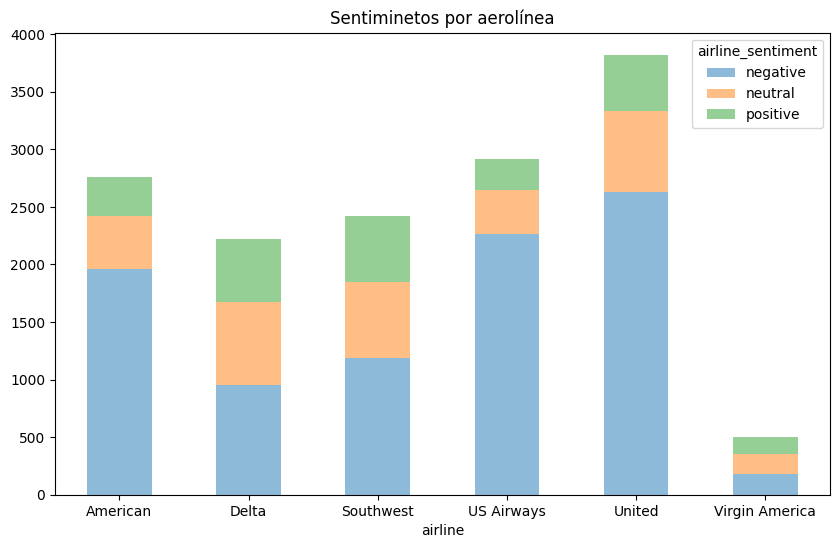

In [7]:
# Plot con cuenta de tweets por cada aerolínea y sentimiento
pd.crosstab(index = tweets["airline"],columns = tweets["airline_sentiment"]).plot(kind='bar',figsize=(10, 6),alpha=0.5,rot=0,stacked=True,title="Sentiminetos por aerolínea")

### Liberias y Variables de interés y predicción

In [8]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from nltk.stem.snowball import SnowballStemmer
from nltk.stem import WordNetLemmatizer
from sklearn.metrics import accuracy_score

In [9]:
# Separación de variables predictoras (X) y de variable de interés (y)
X = tweets['text']
y = tweets['airline_sentiment'].map({'negative':-1,'neutral':0,'positive':1})

In [10]:
# Separación de datos en set de entrenamiento y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

### Punto 1 - Uso de CountVectorizer

En la celda 1 creen un modelo de random forest con la libreria sklearn que prediga el sentimiento de los tweets usando los set de entrenamiento y test definidos anteriormente. Usen la función **CountVectorizer** y presenten el desempeño del modelo con la métrica del acurracy.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

In [11]:
# Celda 1 - CountVectorizer + Random Forest

# Crear vectorizador
vect = CountVectorizer()

# Ajustar con entrenamiento y transformar entrenamiento
X_train_dtm = vect.fit_transform(X_train)

# Transformar test con el mismo vectorizador
X_test_dtm = vect.transform(X_test)

# Crear y entrenar modelo Random Forest
model = RandomForestClassifier(random_state=42)
model.fit(X_train_dtm, y_train)

# Predecir
y_pred = model.predict(X_test_dtm)

# Evaluar con accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy con CountVectorizer: {accuracy:.3f}")

Accuracy con CountVectorizer: 0.771


### Punto 2 - Eliminación de Stopwords

En la celda 2 creen un modelo de random forest con la libreria sklearn que prediga el sentimiento de los tweets usando los set de entrenamiento y test definidos anteriormente. Usen la función CountVectorizer, **eliminen stopwords** y presenten el desempeño del modelo con la métrica del acurracy.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

In [12]:
# Celda 2 - CountVectorizer + eliminación de stopwords

# Crear vectorizador eliminando stopwords
vect_sw = CountVectorizer(stop_words='english')

# Ajustar con entrenamiento
X_train_sw = vect_sw.fit_transform(X_train)

# Transformar test con el mismo vocabulario
X_test_sw = vect_sw.transform(X_test)

# Crear modelo Random Forest (mismo del punto 1)
model_sw = RandomForestClassifier(random_state=42)
model_sw.fit(X_train_sw, y_train)

# Predecir
y_pred_sw = model_sw.predict(X_test_sw)

# Evaluar
accuracy_sw = accuracy_score(y_test, y_pred_sw)

print(f"Accuracy con eliminación de stopwords: {accuracy_sw:.3f}")

Accuracy con eliminación de stopwords: 0.762


### Punto 3 - Lematización con verbos

En la celda 3 creen un modelo de random forest con la libreria sklearn que prediga el sentimiento de los tweets usando los set de entrenamiento y test definidos anteriormente. Usen la función CountVectorizer, **lematizen el texto con verbos** y presenten el desempeño del modelo con la métrica del acurracy.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

In [13]:
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [14]:
# Celda 3 - CountVectorizer + lematización con verbos

from nltk.stem import WordNetLemmatizer

# Crear lematizador
wordnet_lemmatizer = WordNetLemmatizer()

# Función para lematizar cada tweet asumiendo palabras como verbos
def lemmatize_verbs(text):
    words = text.split()
    lemmas = [wordnet_lemmatizer.lemmatize(word, pos='v') for word in words]
    return " ".join(lemmas)

# Aplicar lematización al set de entrenamiento y test
X_train_lemma = X_train.apply(lemmatize_verbs)
X_test_lemma = X_test.apply(lemmatize_verbs)

# Crear vectorizador
vect_lemma = CountVectorizer()

# Ajustar con entrenamiento y transformar entrenamiento
X_train_lemma_dtm = vect_lemma.fit_transform(X_train_lemma)

# Transformar test con el mismo vectorizador
X_test_lemma_dtm = vect_lemma.transform(X_test_lemma)

# Crear y entrenar modelo Random Forest
model_lemma = RandomForestClassifier(random_state=42)
model_lemma.fit(X_train_lemma_dtm, y_train)

# Predecir
y_pred_lemma = model_lemma.predict(X_test_lemma_dtm)

# Evaluar con accuracy
accuracy_lemma = accuracy_score(y_test, y_pred_lemma)

print(f"Accuracy con lematización de verbos: {accuracy_lemma:.3f}")

Accuracy con lematización de verbos: 0.773


### Punto 4 - Multiples técnicas

En la celda 4 creen un modelo de random forest con la libreria sklearn que prediga el sentimiento de los tweets usando los set de entrenamiento y test definidos anteriormente. Usen la función **CountVectorizer, eliminen stopwords, lematizen el texto con verbos** y presenten el desempeño del modelo con la métrica del acurracy.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

In [15]:
# Celda 4 - CountVectorizer + stopwords + lematización con verbos

# Reutilizamos la función lemmatize_verbs creada en el punto 3

# 1. Aplicar lematización a entrenamiento y test
X_train_lemma_sw = X_train.apply(lemmatize_verbs)
X_test_lemma_sw = X_test.apply(lemmatize_verbs)

# 2. Crear vectorizador eliminando stopwords
vect_lemma_sw = CountVectorizer(stop_words='english')

# 3. Ajustar con entrenamiento y transformar entrenamiento
X_train_lemma_sw_dtm = vect_lemma_sw.fit_transform(X_train_lemma_sw)

# 4. Transformar test con el mismo vectorizador
X_test_lemma_sw_dtm = vect_lemma_sw.transform(X_test_lemma_sw)

# 5. Crear y entrenar modelo Random Forest
model_lemma_sw = RandomForestClassifier(random_state=42)
model_lemma_sw.fit(X_train_lemma_sw_dtm, y_train)

# 6. Predecir
y_pred_lemma_sw = model_lemma_sw.predict(X_test_lemma_sw_dtm)

# 7. Evaluar con accuracy
accuracy_lemma_sw = accuracy_score(y_test, y_pred_lemma_sw)

print(f"Accuracy con stopwords y lematización de verbos: {accuracy_lemma_sw:.3f}")

Accuracy con stopwords y lematización de verbos: 0.764


### Punto 5 - Comparación y análisis de resultados

En la celda 5 comparen los resultados obtenidos de los diferentes modelos (random forest) y comenten las ventajas del mejor modelo y las desventajas del modelo con el menor desempeño.

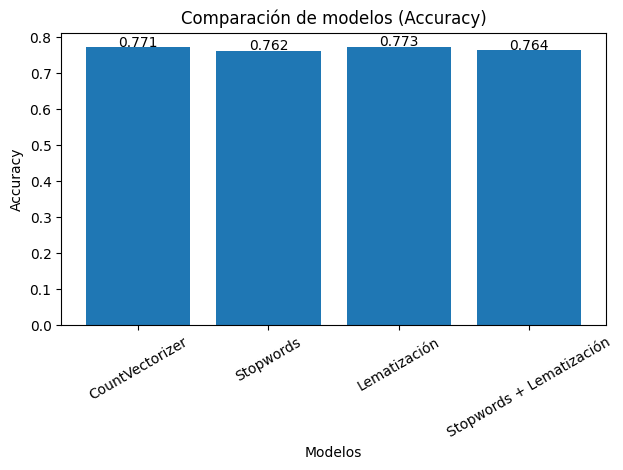

In [16]:
# Celda 5

# Modelos
models = [
    "CountVectorizer",
    "Stopwords",
    "Lematización",
    "Stopwords + Lematización"
]

# Accuracy
accuracies = [
    accuracy,
    accuracy_sw,
    accuracy_lemma,
    accuracy_lemma_sw
]

# Crear gráfico
plt.figure()
bars = plt.bar(models, accuracies)

# Etiquetas
plt.title("Comparación de modelos (Accuracy)")
plt.xlabel("Modelos")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)

# Agregar valores encima de cada barra
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.001, f"{v:.3f}", ha='center')

plt.tight_layout()
plt.show()

## Punto 5 - Comparación y análisis de resultados

Los cuatro modelos rinden prácticamente igual, con accuracies entre 0.762 y 0.773, una diferencia de apenas 0.011 entre el mejor y el peor. Esto sugiere que el preprocesamiento de texto (quitar stopwords, lematizar o combinar ambos) no aporta una mejora real frente al CountVectorizer base en este dataset.
El mejor modelo fue el de Lematización (0.773). Su ventaja principal es que reduce las palabras a su forma raíz (por ejemplo, "volando", "voló" y "volar" se agrupan como "volar"), lo que disminuye la dimensionalidad del vocabulario y permite que el modelo reconozca como equivalentes palabras que comparten significado. Esto ayuda a que tweets con la misma idea pero distinta conjugación aporten evidencia conjunta a la predicción, en lugar de tratarse como features separadas. Además, conserva todas las palabras del tweet, incluidas las negaciones y partículas que cargan polaridad, lo cual es clave en análisis de sentimientos.
El peor modelo fue el de Stopwords (0.762). Su desventaja en este contexto es que las listas estándar de stopwords en inglés suelen incluir palabras como "no", "nunca", "sin", "pero", "muy", que parecen poco informativas pero son justamente las que invierten o intensifican la polaridad de un tweet. Eliminarlas puede transformar un "el vuelo no fue bueno" en "vuelo bueno", borrando información crítica para clasificar correctamente el sentimiento. Por eso aplicar stopwords aquí, sola o combinada con lematización, baja levemente el rendimiento en lugar de mejorarlo.
En resumen: para este problema el preprocesamiento clásico no mueve la aguja, y si se busca mejorar el desempeño conviene apuntar a otras técnicas más complejas en lugar de seguir afinando la limpieza del texto.